<a href="https://colab.research.google.com/github/muhsina419/Machine_learning_-_Parallel_computing_s6/blob/main/Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Question 3: Clustering (Medium)

    a. Apply K-means clustering to group customers based on their purchase history and demographic information.
    b. Determine the optimal number of clusters using the elbow method.
    c. Analyze the characteristics of each cluster to identify customer segments.
    d. Visualize the clusters using scatter plots and dimensionality reduction techniques.
    e. Dataset: https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales



In [1]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")



In [5]:
df = pd.read_csv('supermarket_sales.csv')

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [6]:
print("Dataset Shape:", df.shape)
df.info()
df.isnull().sum()


Dataset Shape: (1000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14 

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


In [7]:


df['Customer_ID'] = df['Gender'] + "_" + df['City'] + "_" + df['Customer type']

customer_df = df.groupby('Customer_ID').agg({
    'Total': ['sum', 'mean'],
    'Quantity': 'sum',
    'Rating': 'mean',
    'Gender': 'first',
    'City': 'first',
    'Customer type': 'first'
})

customer_df.columns = [
    'Total_Spend',
    'Avg_Spend',
    'Total_Quantity',
    'Avg_Rating',
    'Gender',
    'City',
    'Customer_Type'
]

customer_df.reset_index(inplace=True)

customer_df.head()



,Customer_ID,Total_Spend,Avg_Spend,Total_Quantity,Avg_Rating,Gender,City,Customer_Type
0,Female_Mandalay_Member,26850.4320,315.887435,479,6.885882,Female,Mandalay,Member
1,Female_Mandalay_Normal,26077.8630,338.673545,432,6.866234,Female,Mandalay,Normal
2,Female_Naypyitaw_Member,34653.4440,360.973375,548,7.117708,Female,Naypyitaw,Member
3,Female_Naypyitaw_Normal,27032.0190,329.658768,501,7.204878,Female,Naypyitaw,Normal
4,Female_Yangon_Member,26643.0675,333.038344,465,6.786250,Female,Yangon,Member


In [8]:


cluster_df = customer_df.copy()

le = LabelEncoder()

cluster_df['Gender'] = le.fit_transform(cluster_df['Gender'])
cluster_df['City'] = le.fit_transform(cluster_df['City'])
cluster_df['Customer_Type'] = le.fit_transform(cluster_df['Customer_Type'])

cluster_df.head()



,Customer_ID,Total_Spend,Avg_Spend,Total_Quantity,Avg_Rating,Gender,City,Customer_Type
0,Female_Mandalay_Member,26850.4320,315.887435,479,6.885882,0,0,0
1,Female_Mandalay_Normal,26077.8630,338.673545,432,6.866234,0,0,1
2,Female_Naypyitaw_Member,34653.4440,360.973375,548,7.117708,0,1,0
3,Female_Naypyitaw_Normal,27032.0190,329.658768,501,7.204878,0,1,1
4,Female_Yangon_Member,26643.0675,333.038344,465,6.786250,0,2,0


In [9]:
features = [
    'Total_Spend',
    'Avg_Spend',
    'Total_Quantity',
    'Avg_Rating',
    'Gender',
    'City',
    'Customer_Type'
]

X = cluster_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

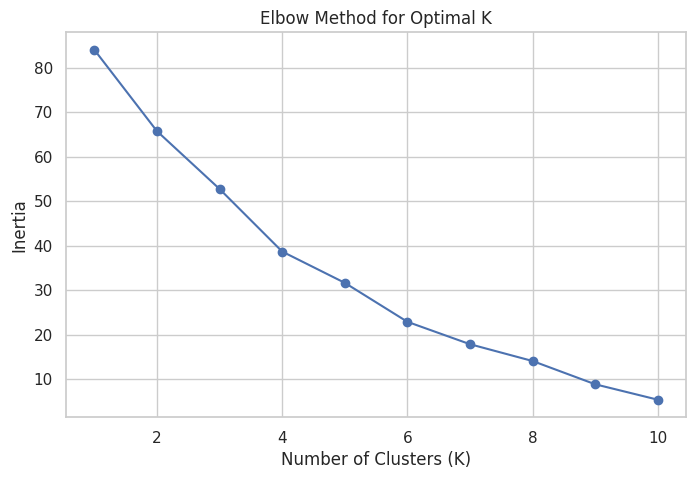

In [10]:


inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()



In [11]:

kmeans = KMeans(n_clusters=4, random_state=42)

cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_df.head()

,Customer_ID,Total_Spend,Avg_Spend,Total_Quantity,Avg_Rating,Gender,City,Customer_Type,Cluster
0,Female_Mandalay_Member,26850.4320,315.887435,479,6.885882,0,0,0,0
1,Female_Mandalay_Normal,26077.8630,338.673545,432,6.866234,0,0,1,1
2,Female_Naypyitaw_Member,34653.4440,360.973375,548,7.117708,0,1,0,2
3,Female_Naypyitaw_Normal,27032.0190,329.658768,501,7.204878,0,1,1,0
4,Female_Yangon_Member,26643.0675,333.038344,465,6.786250,0,2,0,0


In [12]:


pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_df['Cluster']

pca_df.head()



,PC1,PC2,Cluster
0,0.496390,-1.185352,0
1,-0.006586,-1.363883,1
2,4.094817,0.135633,2
3,1.108110,1.110291,0
4,0.632763,-0.545307,0


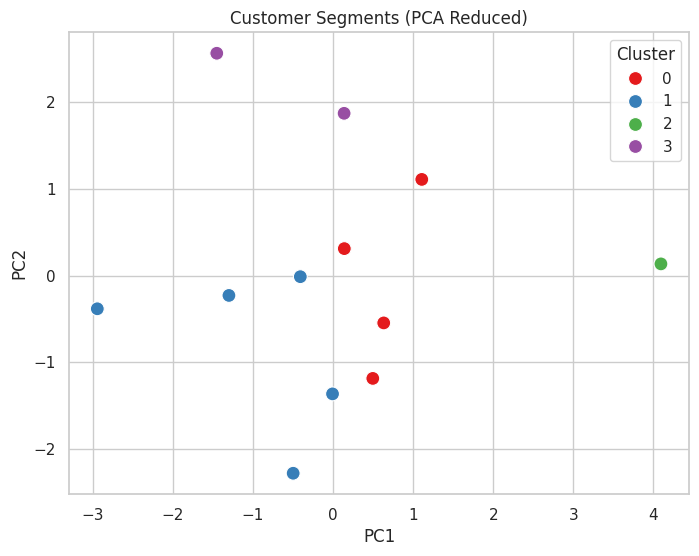

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    data=pca_df,
    s=100
)

plt.title("Customer Segments (PCA Reduced)")
plt.show()